# Exp8.0.4 — Phase-aware hierarchical readout with mean-normalized CE

Protocol: `phase_aware_hierarchical_readout_mean_v1`. This notebook is aggregation-only: it reads finalized artifacts and does not train models or refit probes.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
artifact_dir = root / 'notebooks' / 'artifacts' / 'experiment_8_0_4_phase_aware_hierarchical_readout_mean' / 'phase_aware_hierarchical_readout_mean_v1'
artifact_dir

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_8_0_4_phase_aware_hierarchical_readout_mean/phase_aware_hierarchical_readout_mean_v1')

In [2]:
method = pd.read_csv(artifact_dir / 'method_summary.csv')
probe = pd.read_csv(artifact_dir / 'probe_summary.csv')
paired = pd.read_csv(artifact_dir / 'paired_delta_summary.csv')
phase = pd.read_csv(artifact_dir / 'phase_structure_summary.csv')
history = pd.read_csv(artifact_dir / 'history_runs.csv')
method[['method', 'native_test_ba_mean', 'native_test_ba_std', 'lif_test_ba_mean', 'lif_penalty_mean']]

,method,native_test_ba_mean,native_test_ba_std,lif_test_ba_mean,lif_penalty_mean
0,l2_only_count,0.564502,0.032830,0.524684,0.039817
1,l1_l2_timeshared_count,0.575348,0.034110,0.513261,0.062087
2,l1_fixed250_l2_whole_count,0.586303,0.013987,0.419322,0.166981
3,l1_capacity_no_phase_l2_whole_count,0.579098,0.015863,0.490105,0.088993


## Primary paired comparisons
The first question is whether restoring valid-length mean CE recovers the L2-only baseline. The second is whether `phase_vs_capacity` remains positive.

In [3]:
paired[['comparison', 'native_test_ba_delta_mean', 'native_test_ba_delta_std', 'lif_test_ba_delta_mean', 'target_probe_test_ba_delta_mean']]

,comparison,native_test_ba_delta_mean,native_test_ba_delta_std,lif_test_ba_delta_mean,target_probe_test_ba_delta_mean
0,phase_vs_capacity,0.007205,0.006081,-0.070783,-0.039111
1,phase_vs_timeshared,0.010955,0.025297,-0.093939,-0.032960
2,timeshared_vs_l2,0.010847,0.024515,-0.011423,0.031716


## Representation probes
Show only method-level probe summaries; do not enumerate every seed/run.

In [4]:
features = ['l1_fixed250', 'l2_fixed250', 'l1_l2_fixed250', 'l2_whole', 'l1fixed250_l2whole']
probe_view = probe[probe.feature.isin(features)].pivot(index='method', columns='feature', values='test_ba_mean')
probe_view

feature,l1_fixed250,l1_l2_fixed250,l1fixed250_l2whole,l2_fixed250,l2_whole
method,,,,,
l1_capacity_no_phase_l2_whole_count,0.601983,0.644991,0.645202,0.612098,0.572201
l1_fixed250_l2_whole_count,0.564435,0.593192,0.606091,0.574870,0.526794
l1_l2_timeshared_count,0.585587,0.621361,0.639051,0.605743,0.579755
l2_only_count,0.546985,0.583020,0.607335,0.587253,0.586273


## Phase-bank structure

In [5]:
phase[['method', 'mean_pairwise_cosine_mean', 'mean_adjacent_cosine_mean', 'between_bin_weight_rms_mean']]

,method,mean_pairwise_cosine_mean,mean_adjacent_cosine_mean,between_bin_weight_rms_mean
0,l1_fixed250_l2_whole_count,0.213315,0.454834,0.141443
1,l1_capacity_no_phase_l2_whole_count,0.993945,0.993948,0.012343


## Training curves — method-level mean only

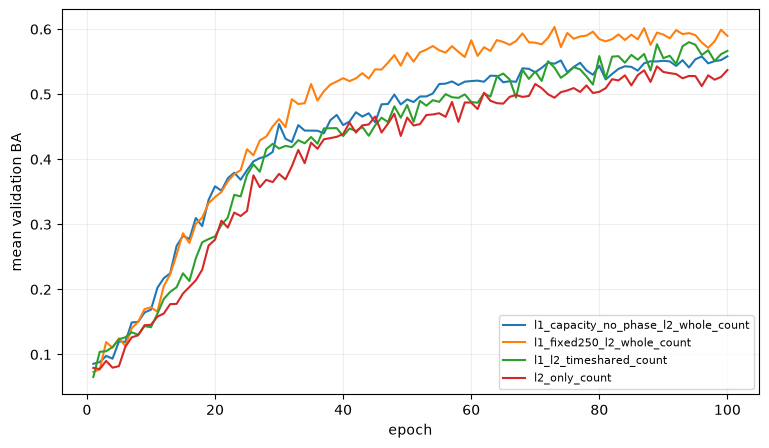

In [6]:
curve = history.groupby(['method', 'epoch'], as_index=False)[['train_ba', 'val_ba', 'train_loss', 'val_loss']].mean()
fig, ax = plt.subplots(figsize=(9, 5))
for name, frame in curve.groupby('method'):
    ax.plot(frame.epoch, frame.val_ba, label=name)
ax.set_xlabel('epoch')
ax.set_ylabel('mean validation BA')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.show()